In [12]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt
#importamos np
import numpy as np


In [13]:
#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 



In [14]:
import numpy as np
from scipy.linalg import qr

def get_pfc_orthogonal_features(X, degree):
    """
    Crea la matriz de diseño P y la transforma en la matriz Q de 
    regresores ortogonales en los puntos de X (Teoría PFC Cap. 4).
    """
    n_samples = X.shape[0]
    # 1. Creamos la matriz de potencias básica (Diseño)
    # Incluimos el término independiente (sesgo) y las potencias
    P = np.ones((n_samples, 1))
    for d in range(1, degree + 1):
        P = np.column_stack((P, X**d))
    
    # 2. Aplicamos la descomposición QR para ortogonalizar
    # Q es la matriz de vectores ortogonales que buscamos
    Q, _ = np.linalg.qr(P)
    
    return Q

In [15]:
def build_pfc_orthogonal_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.BatchNormalization(),
        # Al ser base ortogonal, una capa lineal es extremadamente eficiente
        layers.Dense(1, activation='sigmoid') 
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [16]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [17]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import backend as K
import numpy as np
from tqdm import tqdm

# Configuración
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
results = {2: [], 3: [], 4: []}
histories = {2: [], 3: [], 4: []}

X_np = X.to_numpy() if hasattr(X, 'to_numpy') else X
y_np = y.to_numpy() if hasattr(y, 'to_numpy') else y

for train_index, test_index in tqdm(skf.split(X_np, y_np), total=5):
    X_train_fold, X_test_fold = X_np[train_index], X_np[test_index]
    y_train_fold, y_test_fold = y_np[train_index], y_np[test_index]

    # Convertir etiquetas a binario
    y_train_fold = (y_train_fold == 'g').astype(int)
    y_test_fold = (y_test_fold == 'g').astype(int)

    for deg in [2, 3, 4]:
        K.clear_session()
        
        # --- APLICACIÓN PFC: Ortogonalización en puntos arbitrarios ---
        # Transformamos las características originales en la base ortogonal Q
        # Usamos solo la primera columna de X como ejemplo, o puedes aplanarlas
        X_train_ortho = get_pfc_orthogonal_features(X_train_fold[:, 0], deg)
        X_test_ortho = get_pfc_orthogonal_features(X_test_fold[:, 0], deg)

        # Crear y entrenar
        model = build_pfc_orthogonal_model(X_train_ortho.shape[1])
        
        history = model.fit(
            X_train_ortho, y_train_fold,
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            verbose=0,
            callbacks=[createEarlyStoppingCallback()]
        )
        
        # Evaluar
        _, acc = model.evaluate(X_test_ortho, y_test_fold, verbose=0)
        
        results[deg].append(acc)
        histories[deg].append(history)

# Imprimir resultados finales
for deg in [2, 3, 4]:
    print(f"Grado {deg} (PFC Ortho) | Accuracy: {np.mean(results[deg]):.4f} +/- {np.std(results[deg]):.4f}")

100%|██████████| 5/5 [02:25<00:00, 29.19s/it]

Grado 2 (PFC Ortho) | Accuracy: 0.6493 +/- 0.0017
Grado 3 (PFC Ortho) | Accuracy: 0.6492 +/- 0.0012
Grado 4 (PFC Ortho) | Accuracy: 0.6491 +/- 0.0010


In [18]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

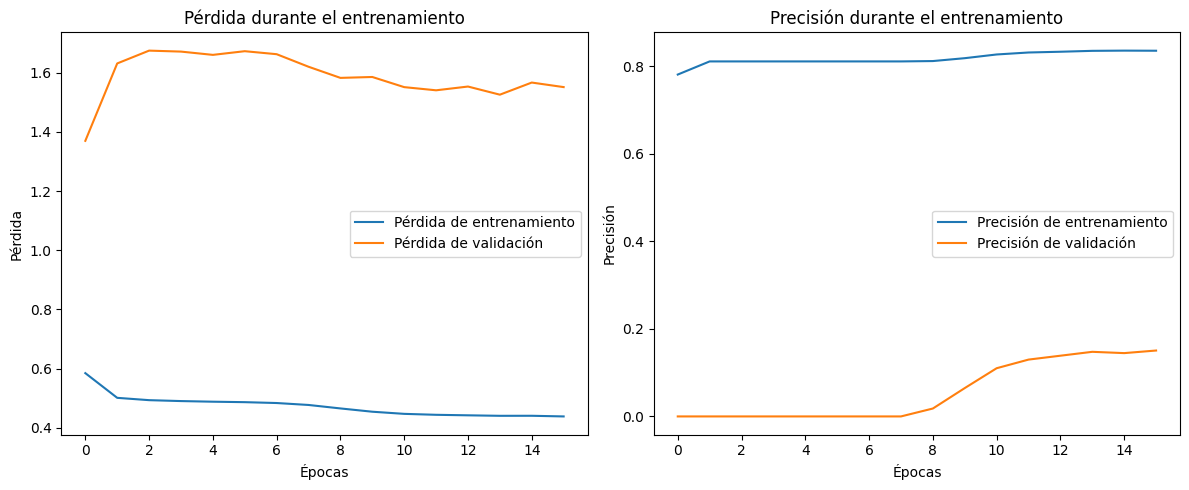

In [23]:
plot_training_history(histories[2][1])  # Ejemplo con el primer fold del grado 2
